<a href="https://colab.research.google.com/github/Nandishwar04/Voyage-Analytics/blob/main/notebooks/Travel_Recommendation%20_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TRAVEL RECOMMENDATION MODEL**

### **INSTALL & IMPORTS**

In [ ]:
# =========================================
# 📦 INSTALL & IMPORTS
# =========================================

!pip install numpy pandas scikit-learn matplotlib seaborn scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
from scipy.sparse.linalg import svds

print('IMPORTS OK')

IMPORTS OK


### **DATA CREATION**

In [ ]:
# =========================================
# 📊 DATA GENERATION
# =========================================

np.random.seed(42)

num_users = 100
num_hotels = 50

df = pd.DataFrame({
    "user_id": np.random.randint(1, num_users+1, 1000),
    "hotel_id": np.random.randint(1, num_hotels+1, 1000),
    "rating": np.random.randint(1, 6, 1000)
})

hotels = pd.DataFrame({
    "hotel_id": range(1, num_hotels+1),
    "price": np.random.randint(1000, 10000, num_hotels),
    "city": np.random.choice(["Chennai","Mumbai","Delhi","Bangalore"], num_hotels),
    "popularity": np.random.randint(1, 100, num_hotels)
})

### **DATA CLEANING**

In [ ]:
# =========================================
# 🧹 DATA CLEANING
# =========================================

print("Missing values:\n", df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())
df = df.drop_duplicates()

df = df[(df['rating'] >= 1) & (df['rating'] <= 5)]

df['user_id'] = df['user_id'].astype(int)
df['hotel_id'] = df['hotel_id'].astype(int)

print("\nCleaning complete")

Missing values:
 user_id     0
hotel_id    0
rating      0
dtype: int64

Duplicates: 27

Cleaning complete


### **FEATURE ENGINEERING**

In [ ]:
# =========================================
# 🔧 FEATURE ENGINEERING (RECOMMENDER-SPECIFIC)
# =========================================

# --- USER FEATURES ---
user_stats = df.groupby('user_id').agg({
    'rating': ['mean', 'count']
})

user_stats.columns = ['user_avg_rating', 'user_interaction_count']


# --- HOTEL FEATURES ---
hotel_stats = df.groupby('hotel_id').agg({
    'rating': ['mean', 'count']
})

hotel_stats.columns = ['hotel_avg_rating', 'hotel_popularity']


# Merge back (optional for analysis / hybrid improvement)
df = df.merge(user_stats, on='user_id', how='left')
df = df.merge(hotel_stats, on='hotel_id', how='left')

df.head()

,user_id,hotel_id,rating,user_avg_rating,user_interaction_count,hotel_avg_rating,hotel_popularity
0,52,34,4,2.250000,12,3.384615,26
1,93,47,2,3.090909,11,2.960000,25
2,15,8,2,3.400000,10,3.000000,21
3,72,40,2,3.250000,8,3.111111,27
4,61,49,2,2.750000,12,3.190476,21


### **EDA**

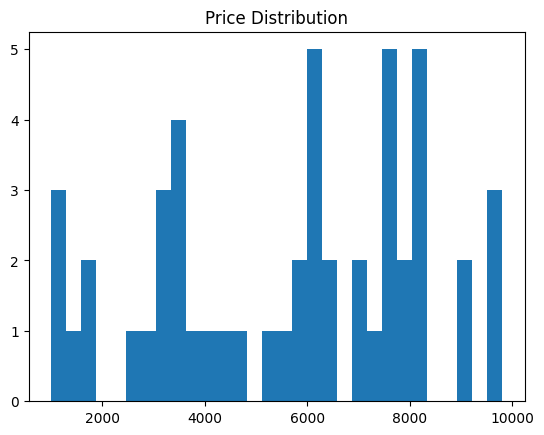

In [ ]:
# =========================================
# 📊 EDA
# =========================================

# Price distribution
plt.hist(hotels['price'], bins=30)
plt.title("Price Distribution")
plt.show()

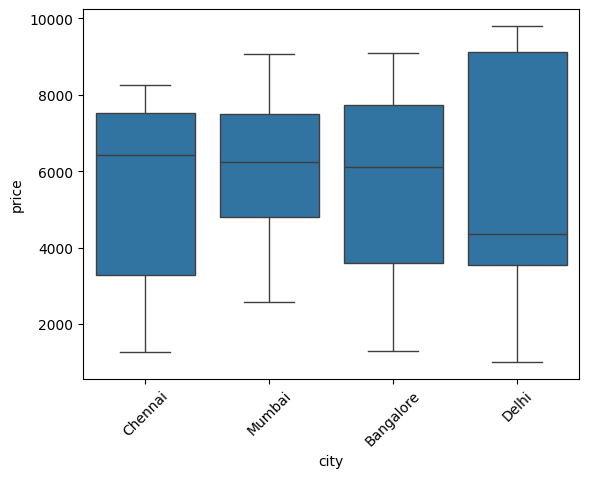

In [ ]:
# Price by city
sns.boxplot(x='city', y='price', data=hotels)
plt.xticks(rotation=45)
plt.show()

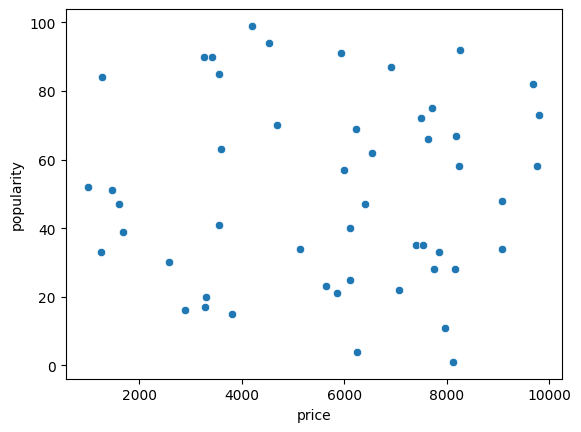

In [ ]:
# Price vs popularity
sns.scatterplot(x='price', y='popularity', data=hotels)
plt.show()

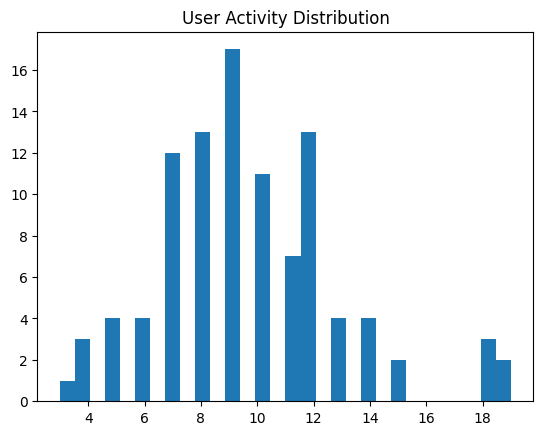

In [ ]:
# User activity (important)
user_activity = df.groupby('user_id')['hotel_id'].count()

plt.hist(user_activity, bins=30)
plt.title("User Activity Distribution")
plt.show()

### **USER-ITEM MATRIX**

In [ ]:
# =========================================
# 🔧 USER-ITEM MATRIX
# =========================================

user_item = df.pivot_table(index='user_id', columns='hotel_id', values='rating').fillna(0)

### **COSINE MODEL**

In [ ]:
# =========================================
# 🤖 COSINE SIMILARITY
# =========================================

cosine_sim = cosine_similarity(user_item)

cosine_df = pd.DataFrame(cosine_sim, index=user_item.index, columns=user_item.index)

def recommend_cosine(user_id, top_n=5):
    if user_id not in cosine_df.index:
        return []

    similar_users = cosine_df[user_id].sort_values(ascending=False)[1:6]
    recs = user_item.loc[similar_users.index].sum().sort_values(ascending=False)

    return recs.head(top_n).index.tolist()

### **SVD MODEL**

In [ ]:
# =========================================
# 🤖 SVD MODEL
# =========================================

matrix = user_item.values

U, sigma, Vt = svds(matrix, k=20)
sigma = np.diag(sigma)

preds = np.dot(np.dot(U, sigma), Vt)

preds_df = pd.DataFrame(preds, index=user_item.index, columns=user_item.columns)

### **CONTENT MODEL**

In [ ]:
# =========================================
# 🔧 FEATURE SCALING (IMPORTANT)
# =========================================

from sklearn.preprocessing import StandardScaler

features = hotels[['price', 'popularity']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

content_sim = cosine_similarity(scaled_features)

content_sim_df = pd.DataFrame(
    content_sim,
    index=hotels['hotel_id'],
    columns=hotels['hotel_id']
)

### **HYBRID MODEL**

In [ ]:
# =========================================
# 🔗 HYBRID MODEL
# =========================================

def recommend_hybrid(user_id, top_n=5):
    if user_id not in preds_df.index:
        return []

    svd_scores = preds_df.loc[user_id]
    top_hotels = svd_scores.sort_values(ascending=False).head(10).index

    scores = {}
    for h in top_hotels:
        scores[h] = float(svd_scores[h] + content_sim_df[h].mean())

    return sorted(scores, key=scores.get, reverse=True)[:top_n]

### **EVALUATION**

In [ ]:
# =========================================
# 📈 EVALUATION
# =========================================

rmse = np.sqrt(mean_squared_error(matrix.flatten(), preds.flatten()))

def precision_at_k(actual, predicted, k=5):
    return len(set(actual) & set(predicted[:k])) / k

### **MODEL COMPARISON**

In [ ]:
# =========================================
# 📊 MODEL COMPARISON
# =========================================

sample_user = user_item.index[0]

actual_items = user_item.loc[sample_user][user_item.loc[sample_user] > 0].index.tolist()

cosine_preds = recommend_cosine(sample_user)
svd_preds = preds_df.loc[sample_user].sort_values(ascending=False).head(5).index.tolist()
hybrid_preds = recommend_hybrid(sample_user)

results = pd.DataFrame({
    "Model": ["Cosine", "SVD", "Hybrid"],
    "RMSE": ["N/A", rmse, rmse],
    "Precision@5": [
        precision_at_k(actual_items, cosine_preds),
        precision_at_k(actual_items, svd_preds),
        precision_at_k(actual_items, hybrid_preds)
    ]
})

results

,Model,RMSE,Precision@5
0,Cosine,N/A,0.8
1,SVD,0.706552,1.0
2,Hybrid,0.706552,1.0


### **SAVE MODELS**

In [ ]:
# =========================================
# 💾 SAVE FOR API
# =========================================

pickle.dump(preds_df, open("preds_df.pkl", "wb"))
pickle.dump(content_sim_df, open("content_sim.pkl", "wb"))

### **FINAL TEST**

In [ ]:
recommend_hybrid(sample_user)

[29, 17, 32, 11, 26]

### **API — api/app.py**

In [ ]:
# =========================================
# API — api/app.py
# =========================================

# Create the 'api' directory if it doesn't exist
!mkdir -p api

# Copy the pickle files into the 'api' directory from the current working directory
!cp preds_df.pkl api/
!cp content_sim.pkl api/

# Python code to write the FastAPI application to 'api/app.py'
app_code = """
from fastapi import FastAPI
import pickle
import os

app = FastAPI()

# Load pickle files assuming they are in the same directory as app.py
# This path is correct because we will 'cd api' before running uvicorn.
preds_df = pickle.load(open("preds_df.pkl", "rb"))
content_sim_df = pickle.load(open("content_sim.pkl", "rb"))

def recommend_hybrid(user_id, top_n=5):
    if user_id not in preds_df.index:
        return []

    svd_scores = preds_df.loc[user_id]
    top_hotels = svd_scores.sort_values(ascending=False).head(10).index

    scores = {}
    for h in top_hotels:
        scores[h] = float(svd_scores[h] + content_sim_df[h].mean())

    return [int(x) for x in sorted(scores, key=scores.get, reverse=True)[:top_n]]

@app.get("/recommend/{user_id}")
def recommend(user_id: int):
    return {"recommendations": recommend_hybrid(user_id)}
"""

with open("api/app.py", "w") as f:
    f.write(app_code)

print("FastAPI application 'api/app.py' created.")

FastAPI application 'api/app.py' created.


### **STREAMLIT — streamlit/app.py**

In [ ]:
!pip install streamlit
import streamlit as st
import requests

st.title("Hotel Recommendation System")

user_id = st.number_input("Enter User ID", min_value=1)

if st.button("Recommend"):
    res = requests.get(f"http://127.0.0.1:8000/recommend/{user_id}")
    data = res.json()

    for i, r in enumerate(data["recommendations"], 1):
        st.write(f"{i}. Hotel {r}")

2026-03-24 16:17:56.652 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 16:17:56.654 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 16:17:56.659 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 16:17:56.664 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 16:17:56.669 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 16:17:56.671 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 16:17:56.676 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 16:17:56.682 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
# =========================================
# 💾 SAVE COMPLETE MODEL (SINGLE FILE)
# =========================================

import pickle
import os

os.makedirs("models", exist_ok=True)

final_model = {
    "preds_df": preds_df,
    "content_sim": content_sim_df,
    "user_item": user_item,
    "hotels": hotels
}

with open("models/final_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

print("✅ final_model.pkl saved successfully")

✅ final_model.pkl saved successfully


In [ ]:
# =========================================
# 🔍 VERIFY LOADING
# =========================================

with open("models/final_model.pkl", "rb") as f:
    loaded = pickle.load(f)

print(loaded.keys())

dict_keys(['preds_df', 'content_sim', 'user_item', 'hotels'])


In [ ]:
# =========================================
# LOAD MODEL (API)
# =========================================

import pickle

with open("models/final_model.pkl", "rb") as f:
    model = pickle.load(f)

preds_df = model["preds_df"]
content_sim = model["content_sim"]
user_item = model["user_item"]
hotels = model["hotels"]

In [ ]:
final_model = {
    "preds_df": preds_df,
    "content_sim": content_sim_df,
    "user_item": user_item,
    "hotels": hotels,
    "version": "1.0",
    "model_type": "hybrid_recommender"
}

In [ ]:
import os
print(os.path.getsize("models/final_model.pkl") / (1024 * 1024), "MB")

0.0998067855834961 MB


### **RUN**

In [ ]:
cd api
uvicorn app:app --reload

In [ ]:
cd api
uvicorn app:app --reload